# Actividad 7 — Diseno del Esquema del Data Warehouse

**Proyecto:** Prediccion de Produccion de Limon en el Peru  
**Pipeline:** Fase 1 — Ingenieria de Datos  

---

## Objetivo
Disenar y documentar la arquitectura del Data Warehouse que almacenara el dataset integrado. Se genera el diagrama UML del Star Schema, el DDL SQL y se documenta cada decision de diseno.

## Regla de esta actividad
> Solo se diseña y documenta. Los datos NO se cargan a PostgreSQL aqui (eso es Actividad 8).


## Configuracion inicial


In [1]:
import os, sys, json, glob, warnings
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

while not os.path.exists('pipeline/config/pipeline_config.json'):
    os.chdir('..')
with open('pipeline/config/pipeline_config.json','r',encoding='utf-8') as f:
    CONFIG = json.load(f)
OUTPUT = CONFIG['output']

os.makedirs(OUTPUT['dwh'], exist_ok=True)
print('Config cargado OK | Raiz:', os.getcwd())
print('Carpeta de salida:', OUTPUT['dwh'])


Config cargado OK | Raiz: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-
Carpeta de salida: pipeline/output/07_dwh/


---
# 1. Justificacion del Modelo Star Schema


## 1.1 Por que Star Schema?

El **Star Schema** (Esquema Estrella) es la arquitectura estandar para Data Warehouses analiticos. Se eligio por las siguientes razones:

| Criterio | Star Schema | Modelo Plano (CSV) |
|----------|-------------|--------------------|
| Consultas analiticas | Optimizado (JOINs simples) | Lento (escaneo completo) |
| Redundancia de datos | Minima (datos en dimensiones) | Alta (datos repetidos) |
| Mantenimiento | Facil (actualizar dimension) | Dificil (actualizar todo el CSV) |
| Compatibilidad BI | Total (Tableau, Power BI) | Limitada |
| Extensibilidad | Alta (agregar dimensiones) | Baja |

## 1.2 Estructura del Star Schema

```
                    dim_tiempo
                        |
dim_noticias --- fact_produccion_limon --- dim_clima
                        |
              dim_ubicacion --- dim_emergencia
```

- **1 Tabla de Hechos:** `fact_produccion_limon` — metricas numericas
- **5 Dimensiones:** tiempo, ubicacion, clima, emergencia, noticias

## 1.3 Decisiones de diseno documentadas

| Decision | Justificacion |
|----------|---------------|
| Separar clima en dimension propia | Las 8 variables NASA son un grupo coherente |
| Separar emergencias en dimension propia | INDECI tiene su propio ciclo de actualizacion |
| `avg_sentimiento` en dim_noticias | Reservado para Fase 2 (BETO) — NULL en Fase 1 |
| `month_sin/cos` NO incluidos | Son variables de Fase 2, no del DWH de Fase 1 |
| Granularidad mensual por provincia | Coincide con la granularidad del dataset integrado |


---
# 2. Diagrama UML del Star Schema


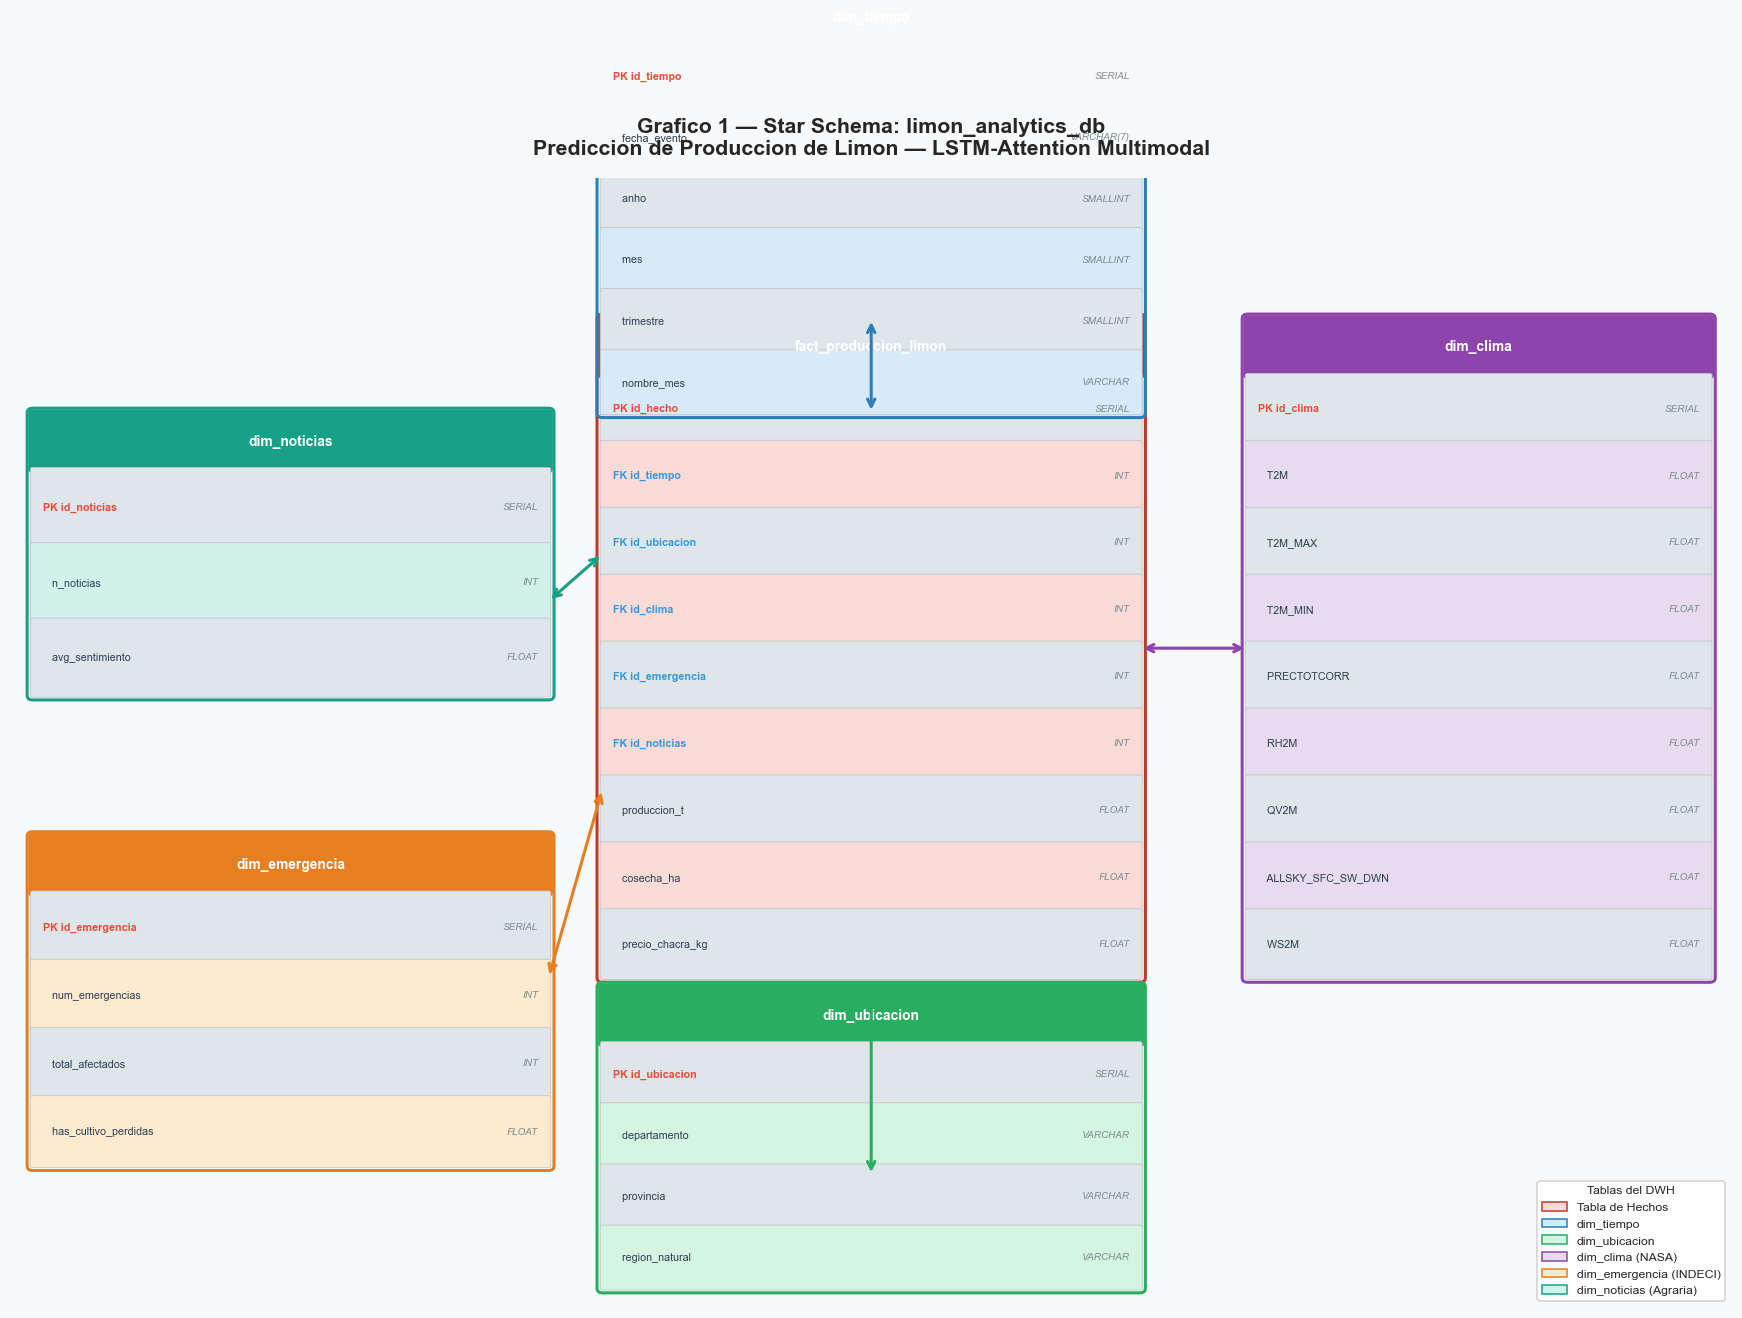

Guardado: pipeline/output/07_dwh/star_schema_uml.png


In [2]:
# ── GRAFICO 1: Diagrama UML del Star Schema ──────────────────────────────
fig, ax = plt.subplots(figsize=(16, 12))
ax.set_xlim(0, 16)
ax.set_ylim(0, 12)
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

def draw_table(ax, x, y, w, h, title, cols, color_header='#2c3e50', color_body='#ecf0f1'):
    row_h = (h - 0.6) / len(cols)
    # Header
    header = FancyBboxPatch((x, y + h - 0.6), w, 0.6,
                             boxstyle='round,pad=0.05', facecolor=color_header,
                             edgecolor='white', linewidth=1.5)
    ax.add_patch(header)
    ax.text(x + w/2, y + h - 0.3, title, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')
    # Rows
    for i, (col_name, col_type, is_key) in enumerate(cols):
        row_y = y + h - 0.6 - (i+1)*row_h
        bg = '#dfe6e9' if i % 2 == 0 else color_body
        row = FancyBboxPatch((x, row_y), w, row_h,
                              boxstyle='round,pad=0.02', facecolor=bg,
                              edgecolor='#bdc3c7', linewidth=0.5)
        ax.add_patch(row)
        prefix = 'PK ' if is_key == 'PK' else 'FK ' if is_key == 'FK' else '   '
        color_txt = '#e74c3c' if is_key == 'PK' else '#3498db' if is_key == 'FK' else '#2c3e50'
        ax.text(x + 0.1, row_y + row_h/2, f'{prefix}{col_name}',
                ha='left', va='center', fontsize=7, color=color_txt, fontweight='bold' if is_key else 'normal')
        ax.text(x + w - 0.1, row_y + row_h/2, col_type,
                ha='right', va='center', fontsize=6.5, color='#7f8c8d', style='italic')
    # Border
    border = FancyBboxPatch((x, y), w, h,
                             boxstyle='round,pad=0.05', fill=False,
                             edgecolor=color_header, linewidth=2)
    ax.add_patch(border)

# ── Tabla de Hechos (centro) ──────────────────────────────────────────────
fact_cols = [
    ('id_hecho',     'SERIAL',  'PK'),
    ('id_tiempo',    'INT',     'FK'),
    ('id_ubicacion', 'INT',     'FK'),
    ('id_clima',     'INT',     'FK'),
    ('id_emergencia','INT',     'FK'),
    ('id_noticias',  'INT',     'FK'),
    ('produccion_t', 'FLOAT',   ''),
    ('cosecha_ha',   'FLOAT',   ''),
    ('precio_chacra_kg','FLOAT',''),
]
draw_table(ax, 5.5, 3.5, 5, 7, 'fact_produccion_limon', fact_cols,
           color_header='#c0392b', color_body='#fadbd8')

# ── dim_tiempo (arriba) ───────────────────────────────────────────────────
tiempo_cols = [
    ('id_tiempo',   'SERIAL',    'PK'),
    ('fecha_evento','VARCHAR(7)',''),
    ('anho',        'SMALLINT',  ''),
    ('mes',         'SMALLINT',  ''),
    ('trimestre',   'SMALLINT',  ''),
    ('nombre_mes',  'VARCHAR',   ''),
]
draw_table(ax, 5.5, 9.5, 5, 4.5, 'dim_tiempo', tiempo_cols,
           color_header='#2980b9', color_body='#d6eaf8')

# ── dim_ubicacion (abajo) ─────────────────────────────────────────────────
ubic_cols = [
    ('id_ubicacion', 'SERIAL',   'PK'),
    ('departamento', 'VARCHAR',  ''),
    ('provincia',    'VARCHAR',  ''),
    ('region_natural','VARCHAR', ''),
]
draw_table(ax, 5.5, 0.2, 5, 3.2, 'dim_ubicacion', ubic_cols,
           color_header='#27ae60', color_body='#d5f5e3')

# ── dim_clima (derecha) ───────────────────────────────────────────────────
clima_cols = [
    ('id_clima',          'SERIAL','PK'),
    ('T2M',               'FLOAT', ''),
    ('T2M_MAX',           'FLOAT', ''),
    ('T2M_MIN',           'FLOAT', ''),
    ('PRECTOTCORR',       'FLOAT', ''),
    ('RH2M',              'FLOAT', ''),
    ('QV2M',              'FLOAT', ''),
    ('ALLSKY_SFC_SW_DWN', 'FLOAT', ''),
    ('WS2M',              'FLOAT', ''),
]
draw_table(ax, 11.5, 3.5, 4.3, 7, 'dim_clima', clima_cols,
           color_header='#8e44ad', color_body='#e8daef')

# ── dim_emergencia (izquierda abajo) ──────────────────────────────────────
emer_cols = [
    ('id_emergencia',      'SERIAL','PK'),
    ('num_emergencias',    'INT',   ''),
    ('total_afectados',    'INT',   ''),
    ('has_cultivo_perdidas','FLOAT',''),
]
draw_table(ax, 0.2, 1.5, 4.8, 3.5, 'dim_emergencia', emer_cols,
           color_header='#e67e22', color_body='#fdebd0')

# ── dim_noticias (izquierda arriba) ───────────────────────────────────────
not_cols = [
    ('id_noticias',    'SERIAL','PK'),
    ('n_noticias',     'INT',   ''),
    ('avg_sentimiento','FLOAT', ''),
]
draw_table(ax, 0.2, 6.5, 4.8, 3, 'dim_noticias', not_cols,
           color_header='#16a085', color_body='#d1f2eb')

# ── Flechas FK ────────────────────────────────────────────────────────────
arrow_props = dict(arrowstyle='->', color='#7f8c8d', lw=1.5,
                   connectionstyle='arc3,rad=0.0')
# fact -> dim_tiempo
ax.annotate('', xy=(8, 9.5), xytext=(8, 10.5),
            arrowprops=dict(arrowstyle='<->', color='#2980b9', lw=2))
# fact -> dim_ubicacion
ax.annotate('', xy=(8, 3.5), xytext=(8, 1.4),
            arrowprops=dict(arrowstyle='<->', color='#27ae60', lw=2))
# fact -> dim_clima
ax.annotate('', xy=(11.5, 7), xytext=(10.5, 7),
            arrowprops=dict(arrowstyle='<->', color='#8e44ad', lw=2))
# fact -> dim_emergencia
ax.annotate('', xy=(5.5, 5.5), xytext=(5.0, 3.5),
            arrowprops=dict(arrowstyle='<->', color='#e67e22', lw=2))
# fact -> dim_noticias
ax.annotate('', xy=(5.5, 8), xytext=(5.0, 7.5),
            arrowprops=dict(arrowstyle='<->', color='#16a085', lw=2))

# Titulo y leyenda
ax.set_title('Grafico 1 — Star Schema: limon_analytics_db\n'
             'Prediccion de Produccion de Limon — LSTM-Attention Multimodal',
             fontsize=14, fontweight='bold', pad=15)

legend_elements = [
    mpatches.Patch(facecolor='#fadbd8', edgecolor='#c0392b', label='Tabla de Hechos'),
    mpatches.Patch(facecolor='#d6eaf8', edgecolor='#2980b9', label='dim_tiempo'),
    mpatches.Patch(facecolor='#d5f5e3', edgecolor='#27ae60', label='dim_ubicacion'),
    mpatches.Patch(facecolor='#e8daef', edgecolor='#8e44ad', label='dim_clima (NASA)'),
    mpatches.Patch(facecolor='#fdebd0', edgecolor='#e67e22', label='dim_emergencia (INDECI)'),
    mpatches.Patch(facecolor='#d1f2eb', edgecolor='#16a085', label='dim_noticias (Agraria)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
          framealpha=0.9, title='Tablas del DWH', title_fontsize=8)

plt.tight_layout()
g1 = OUTPUT['dwh'] + 'star_schema_uml.png'
plt.savefig(g1, dpi=130, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print('Guardado:', g1)


### Interpretacion

**Que muestra:** El diagrama UML del Star Schema con las 5 dimensiones y la tabla de hechos. Las flechas bidireccionales indican las relaciones de clave foranea.

**Decisiones de diseno:**
- La tabla de hechos solo contiene metricas numericas y claves foraneas.
- Cada dimension agrupa variables del mismo origen (NASA → dim_clima, INDECI → dim_emergencia).
- `avg_sentimiento` en dim_noticias esta reservado para la Fase 2 (BETO) y sera NULL en Fase 1.

**Implicacion para el pipeline:** Este esquema es el que se creara en PostgreSQL en la Actividad 8 y se cargara con datos en la Actividad 9.


---
# 3. Cardinalidad de las Tablas

Cuantas filas tendra cada tabla en PostgreSQL basado en el dataset integrado.


In [3]:
df_int = pd.read_csv(OUTPUT['integracion'] + 'dataset_integrado.csv')
print(f'Dataset integrado: {df_int.shape}')
print(f'Columnas: {df_int.columns.tolist()}')
print()

# Calcular cardinalidad de cada tabla
n_hechos     = len(df_int)
n_tiempo     = df_int['fecha_evento'].nunique()
n_ubicacion  = df_int[['departamento','provincia']].drop_duplicates().shape[0]
n_clima      = n_hechos  # una fila de clima por hecho
n_emergencia = n_hechos  # una fila de emergencia por hecho
n_noticias   = n_tiempo  # una fila de noticias por mes (nacional)

print('Cardinalidad esperada de cada tabla:')
print(f'  fact_produccion_limon : {n_hechos:,} filas')
print(f'  dim_tiempo            : {n_tiempo:,} filas ({n_tiempo} meses unicos)')
print(f'  dim_ubicacion         : {n_ubicacion:,} filas ({n_ubicacion} provincias unicas)')
print(f'  dim_clima             : {n_clima:,} filas (una por hecho)')
print(f'  dim_emergencia        : {n_emergencia:,} filas (una por hecho)')
print(f'  dim_noticias          : {n_noticias:,} filas (una por mes)')


Dataset integrado: (5880, 17)
Columnas: ['fecha_evento', 'departamento', 'provincia', 'produccion_t', 'cosecha_ha', 'precio_chacra_kg', 'num_emergencias', 'total_afectados', 'ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'QV2M', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'WS2M', 'n_noticias']

Cardinalidad esperada de cada tabla:
  fact_produccion_limon : 5,880 filas
  dim_tiempo            : 56 filas (56 meses unicos)
  dim_ubicacion         : 105 filas (105 provincias unicas)
  dim_clima             : 5,880 filas (una por hecho)
  dim_emergencia        : 5,880 filas (una por hecho)
  dim_noticias          : 56 filas (una por mes)


## Grafico 2 — Cardinalidad de cada tabla del DWH


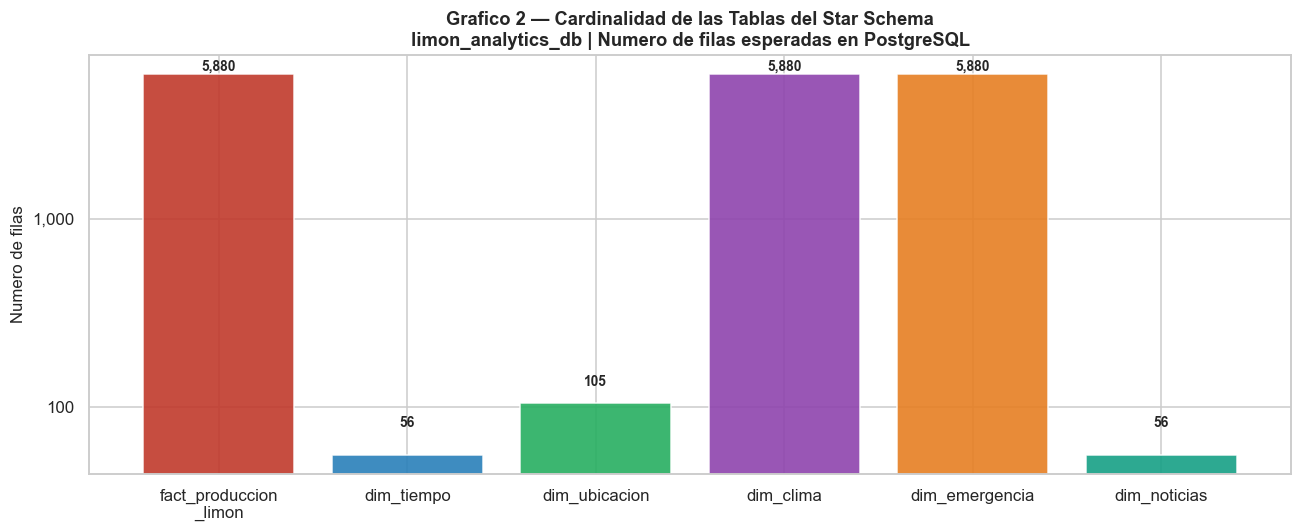

Guardado: pipeline/output/07_dwh/cardinalidad_tablas.png


In [4]:
tablas = ['fact_produccion\n_limon', 'dim_tiempo', 'dim_ubicacion',
          'dim_clima', 'dim_emergencia', 'dim_noticias']
valores = [n_hechos, n_tiempo, n_ubicacion, n_clima, n_emergencia, n_noticias]
colores = ['#c0392b','#2980b9','#27ae60','#8e44ad','#e67e22','#16a085']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(tablas, valores, color=colores, edgecolor='white', alpha=0.9)
for bar, val in zip(bars, valores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Numero de filas', fontsize=11)
ax.set_title('Grafico 2 — Cardinalidad de las Tablas del Star Schema\n'
             'limon_analytics_db | Numero de filas esperadas en PostgreSQL',
             fontsize=12, fontweight='bold')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
g2 = OUTPUT['dwh'] + 'cardinalidad_tablas.png'
plt.savefig(g2, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g2)


### Interpretacion

**Que muestra:** El numero de filas que tendra cada tabla en PostgreSQL. La escala logaritmica permite ver las diferencias entre tablas grandes y pequenas.

**Implicacion para el pipeline:** La tabla de hechos y las dimensiones de clima y emergencia tienen la misma cardinalidad porque hay una fila de cada una por cada hecho. dim_tiempo y dim_noticias son mucho mas pequenas (una fila por mes).

**Implicacion para el modelo:** La cardinalidad del DWH determina el tamano de las consultas SQL que se usaran para extraer datos en la Actividad 9.


---
# 4. Mapeo Dataset Integrado → Star Schema

Que columna del `dataset_integrado.csv` va a que tabla del DWH.


In [5]:
mapeo = [
    ('fecha_evento',         'dim_tiempo',          'fecha_evento (llave natural)'),
    ('departamento',         'dim_ubicacion',        'departamento'),
    ('provincia',            'dim_ubicacion',        'provincia'),
    ('produccion_t',         'fact_produccion_limon','produccion_t'),
    ('cosecha_ha',           'fact_produccion_limon','cosecha_ha'),
    ('precio_chacra_kg',     'fact_produccion_limon','precio_chacra_kg'),
    ('num_emergencias',      'dim_emergencia',       'num_emergencias'),
    ('total_afectados',      'dim_emergencia',       'total_afectados'),
    ('has_cultivo_perdidas', 'dim_emergencia',       'has_cultivo_perdidas'),
    ('n_noticias',           'dim_noticias',         'n_noticias'),
    ('T2M',                  'dim_clima',            'T2M'),
    ('T2M_MAX',              'dim_clima',            'T2M_MAX'),
    ('T2M_MIN',              'dim_clima',            'T2M_MIN'),
    ('PRECTOTCORR',          'dim_clima',            'PRECTOTCORR'),
    ('RH2M',                 'dim_clima',            'RH2M'),
    ('QV2M',                 'dim_clima',            'QV2M'),
    ('ALLSKY_SFC_SW_DWN',    'dim_clima',            'ALLSKY_SFC_SW_DWN'),
    ('WS2M',                 'dim_clima',            'WS2M'),
]

df_mapeo = pd.DataFrame(mapeo, columns=['Columna CSV','Tabla DWH','Columna DWH'])
print('Mapeo dataset_integrado.csv → Star Schema:')
display(df_mapeo)

# Verificar que todas las columnas del CSV estan mapeadas
cols_csv = set(df_int.columns)
cols_mapeadas = set(df_mapeo['Columna CSV'])
no_mapeadas = cols_csv - cols_mapeadas
print()
if no_mapeadas:
    print(f'Columnas del CSV sin mapear: {no_mapeadas}')
else:
    print('OK: Todas las columnas del CSV estan mapeadas al Star Schema.')


Mapeo dataset_integrado.csv → Star Schema:


,Columna CSV,Tabla DWH,Columna DWH
0,fecha_evento,dim_tiempo,fecha_evento (llave natural)
1,departamento,dim_ubicacion,departamento
2,provincia,dim_ubicacion,provincia
3,produccion_t,fact_produccion_limon,produccion_t
4,cosecha_ha,fact_produccion_limon,cosecha_ha
5,precio_chacra_kg,fact_produccion_limon,precio_chacra_kg
6,num_emergencias,dim_emergencia,num_emergencias
7,total_afectados,dim_emergencia,total_afectados
8,has_cultivo_perdidas,dim_emergencia,has_cultivo_perdidas
9,n_noticias,dim_noticias,n_noticias



OK: Todas las columnas del CSV estan mapeadas al Star Schema.


## Grafico 3 — Mapeo visual dataset → Star Schema


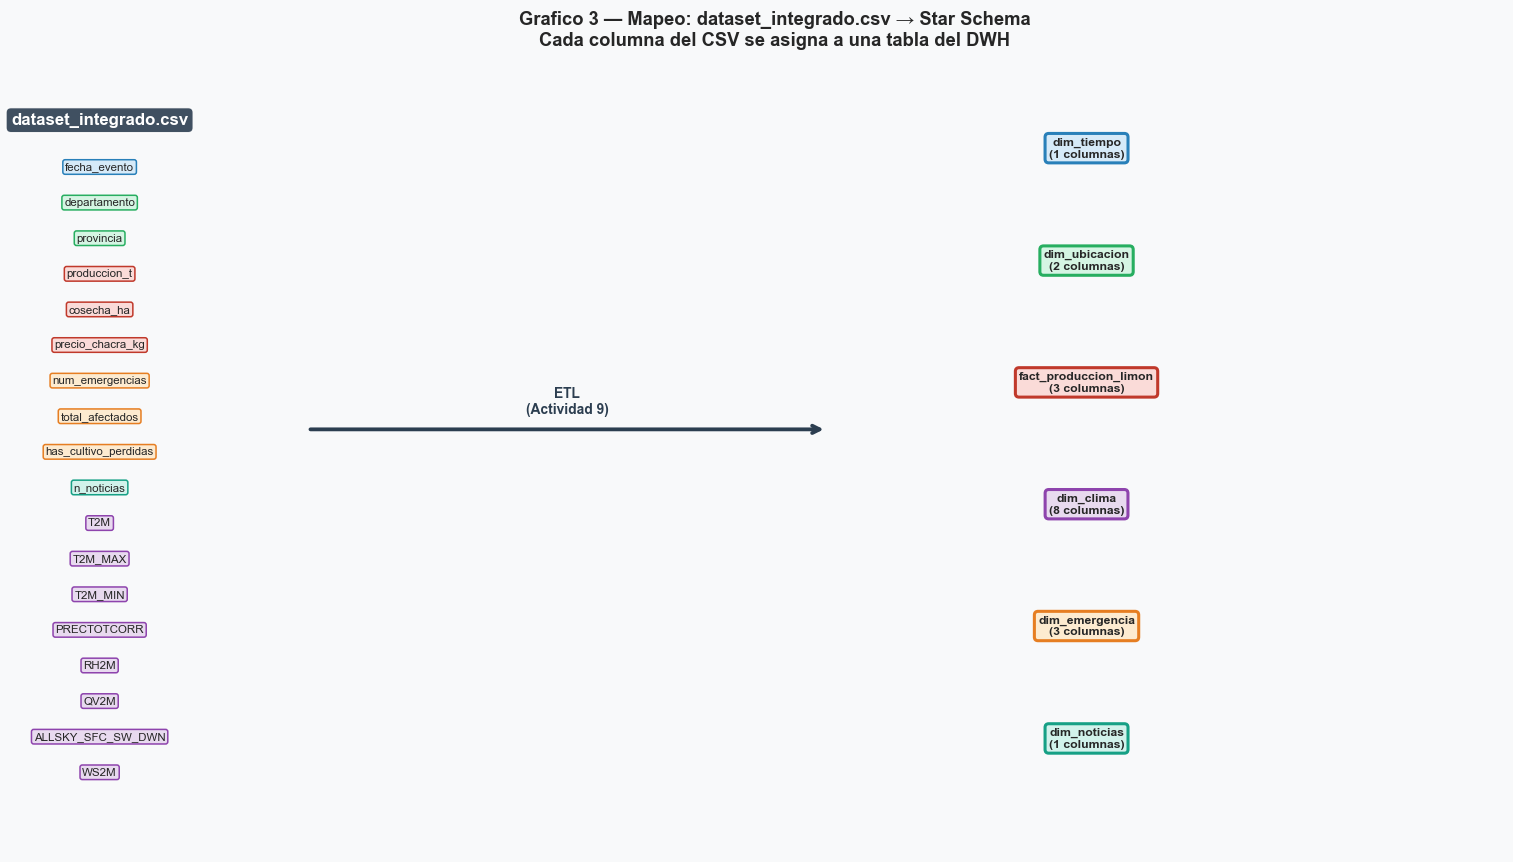

Guardado: pipeline/output/07_dwh/mapeo_csv_dwh.png


In [6]:
import matplotlib
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

# Agrupar por tabla destino
grupos = df_mapeo.groupby('Tabla DWH')['Columna CSV'].apply(list).to_dict()
colores_tablas = {
    'fact_produccion_limon': '#fadbd8',
    'dim_tiempo':            '#d6eaf8',
    'dim_ubicacion':         '#d5f5e3',
    'dim_clima':             '#e8daef',
    'dim_emergencia':        '#fdebd0',
    'dim_noticias':          '#d1f2eb',
}
bordes_tablas = {
    'fact_produccion_limon': '#c0392b',
    'dim_tiempo':            '#2980b9',
    'dim_ubicacion':         '#27ae60',
    'dim_clima':             '#8e44ad',
    'dim_emergencia':        '#e67e22',
    'dim_noticias':          '#16a085',
}

# Panel izquierdo: columnas del CSV
ax.text(0.5, 7.8, 'dataset_integrado.csv', ha='center', va='center',
        fontsize=11, fontweight='bold', color='white',
        bbox=dict(boxstyle='round', facecolor='#2c3e50', alpha=0.9))
for i, col in enumerate(df_mapeo['Columna CSV']):
    y_pos = 7.3 - i * 0.38
    tabla = df_mapeo[df_mapeo['Columna CSV']==col]['Tabla DWH'].values[0]
    color = bordes_tablas.get(tabla, '#7f8c8d')
    ax.text(0.5, y_pos, col, ha='center', va='center', fontsize=7.5,
            bbox=dict(boxstyle='round,pad=0.2', facecolor=colores_tablas.get(tabla,'white'),
                      edgecolor=color, linewidth=1))

# Panel derecho: tablas del DWH
tablas_orden = ['dim_tiempo','dim_ubicacion','fact_produccion_limon',
                'dim_clima','dim_emergencia','dim_noticias']
y_tablas = [7.5, 6.3, 5.0, 3.7, 2.4, 1.2]
for tabla, y_t in zip(tablas_orden, y_tablas):
    cols_tabla = grupos.get(tabla, [])
    color_b = bordes_tablas.get(tabla, '#7f8c8d')
    color_f = colores_tablas.get(tabla, 'white')
    ax.text(10, y_t, f'{tabla}\n({len(cols_tabla)} columnas)',
            ha='center', va='center', fontsize=8, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color_f,
                      edgecolor=color_b, linewidth=2))

# Flecha central
ax.annotate('', xy=(7.5, 4.5), xytext=(2.5, 4.5),
            arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2.5))
ax.text(5, 4.8, 'ETL\n(Actividad 9)', ha='center', va='center',
        fontsize=9, fontweight='bold', color='#2c3e50')

ax.set_xlim(0, 14)
ax.set_ylim(0, 8.5)
ax.set_title('Grafico 3 — Mapeo: dataset_integrado.csv → Star Schema\n'
             'Cada columna del CSV se asigna a una tabla del DWH',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g3 = OUTPUT['dwh'] + 'mapeo_csv_dwh.png'
plt.savefig(g3, dpi=120, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print('Guardado:', g3)


### Interpretacion

**Que muestra:** El mapeo de cada columna del dataset integrado a su tabla correspondiente en el Star Schema. El color de cada columna indica a que tabla pertenece.

**Implicacion para el pipeline:** Este mapeo es la guia que seguira el ETL de la Actividad 9 para insertar los datos en PostgreSQL. Cada columna del CSV se convierte en una fila en la dimension correspondiente o en una metrica en la tabla de hechos.

**Implicacion para el modelo:** El Star Schema permite consultas SQL eficientes para extraer subconjuntos del dataset (por departamento, por periodo, por variable climatica) sin necesidad de cargar todo el CSV en memoria.


---
# 5. Generacion del DDL SQL

El DDL (Data Definition Language) es el SQL que crea las tablas en PostgreSQL. Se genera automaticamente desde Python para garantizar consistencia con el diseno.


In [7]:
ddl = '''
-- =================================================================
-- STAR SCHEMA: limon_analytics_db
-- Proyecto: Prediccion de Produccion de Limon — LSTM-Attention
-- Generado por: Pipeline Fase 1 — Actividad 7
-- =================================================================

-- 1. Dimension Tiempo
CREATE TABLE IF NOT EXISTS dim_tiempo (
    id_tiempo     SERIAL PRIMARY KEY,
    fecha_evento  VARCHAR(7)  NOT NULL UNIQUE,
    anho          SMALLINT    NOT NULL,
    mes           SMALLINT    NOT NULL,
    trimestre     SMALLINT    GENERATED ALWAYS AS (((mes - 1) / 3) + 1) STORED,
    nombre_mes    VARCHAR(20)
);

-- 2. Dimension Ubicacion
CREATE TABLE IF NOT EXISTS dim_ubicacion (
    id_ubicacion  SERIAL PRIMARY KEY,
    departamento  VARCHAR(60) NOT NULL,
    provincia     VARCHAR(60) NOT NULL,
    region_natural VARCHAR(20),
    UNIQUE (departamento, provincia)
);

-- 3. Dimension Clima (NASA POWER)
CREATE TABLE IF NOT EXISTS dim_clima (
    id_clima              SERIAL PRIMARY KEY,
    T2M                   FLOAT,
    T2M_MAX               FLOAT,
    T2M_MIN               FLOAT,
    PRECTOTCORR           FLOAT,
    RH2M                  FLOAT,
    QV2M                  FLOAT,
    ALLSKY_SFC_SW_DWN     FLOAT,
    WS2M                  FLOAT
);

-- 4. Dimension Emergencia (INDECI)
CREATE TABLE IF NOT EXISTS dim_emergencia (
    id_emergencia         SERIAL PRIMARY KEY,
    num_emergencias       INT     DEFAULT 0,
    total_afectados       INT     DEFAULT 0,
    has_cultivo_perdidas  FLOAT   DEFAULT 0
);

-- 5. Dimension Noticias (Agraria.pe)
CREATE TABLE IF NOT EXISTS dim_noticias (
    id_noticias           SERIAL PRIMARY KEY,
    n_noticias            INT     DEFAULT 0,
    avg_sentimiento       FLOAT   -- NULL en Fase 1, se llena en Fase 2 con BETO
);

-- 6. Tabla de Hechos
CREATE TABLE IF NOT EXISTS fact_produccion_limon (
    id_hecho              SERIAL PRIMARY KEY,
    id_tiempo             INT NOT NULL REFERENCES dim_tiempo(id_tiempo),
    id_ubicacion          INT NOT NULL REFERENCES dim_ubicacion(id_ubicacion),
    id_clima              INT REFERENCES dim_clima(id_clima),
    id_emergencia         INT REFERENCES dim_emergencia(id_emergencia),
    id_noticias           INT REFERENCES dim_noticias(id_noticias),
    produccion_t          FLOAT   DEFAULT 0,
    cosecha_ha            FLOAT   DEFAULT 0,
    precio_chacra_kg      FLOAT,
    UNIQUE (id_tiempo, id_ubicacion)
);

-- Indices para optimizar consultas de series temporales
CREATE INDEX IF NOT EXISTS idx_fact_tiempo     ON fact_produccion_limon(id_tiempo);
CREATE INDEX IF NOT EXISTS idx_fact_ubicacion  ON fact_produccion_limon(id_ubicacion);
CREATE INDEX IF NOT EXISTS idx_fact_clima      ON fact_produccion_limon(id_clima);
CREATE INDEX IF NOT EXISTS idx_fact_emergencia ON fact_produccion_limon(id_emergencia);
CREATE INDEX IF NOT EXISTS idx_fact_noticias   ON fact_produccion_limon(id_noticias);
CREATE INDEX IF NOT EXISTS idx_tiempo_fecha    ON dim_tiempo(fecha_evento);
CREATE INDEX IF NOT EXISTS idx_ubic_dpto_prov  ON dim_ubicacion(departamento, provincia);
'''

# Guardar el DDL
sql_path = OUTPUT['dwh'] + 'dwh_star_schema.sql'
with open(sql_path, 'w', encoding='utf-8') as f:
    f.write(ddl)

print(f'DDL guardado en: {sql_path}')
print(f'Tamano: {os.path.getsize(sql_path)} bytes')
print()
print('Contenido del DDL:')
print(ddl)


DDL guardado en: pipeline/output/07_dwh/dwh_star_schema.sql
Tamano: 3163 bytes

Contenido del DDL:

-- =================================================================
-- STAR SCHEMA: limon_analytics_db
-- Proyecto: Prediccion de Produccion de Limon — LSTM-Attention
-- Generado por: Pipeline Fase 1 — Actividad 7
-- =================================================================

-- 1. Dimension Tiempo
CREATE TABLE IF NOT EXISTS dim_tiempo (
    id_tiempo     SERIAL PRIMARY KEY,
    fecha_evento  VARCHAR(7)  NOT NULL UNIQUE,
    anho          SMALLINT    NOT NULL,
    mes           SMALLINT    NOT NULL,
    trimestre     SMALLINT    GENERATED ALWAYS AS (((mes - 1) / 3) + 1) STORED,
    nombre_mes    VARCHAR(20)
);

-- 2. Dimension Ubicacion
CREATE TABLE IF NOT EXISTS dim_ubicacion (
    id_ubicacion  SERIAL PRIMARY KEY,
    departamento  VARCHAR(60) NOT NULL,
    provincia     VARCHAR(60) NOT NULL,
    region_natural VARCHAR(20),
    UNIQUE (departamento, provincia)
);

-- 3. Dimensi

### Interpretacion

**Que muestra:** El DDL SQL completo que crea las 6 tablas del Star Schema en PostgreSQL. Incluye PRIMARY KEY, FOREIGN KEY, UNIQUE constraints e indices para optimizar consultas.

**Decisiones de diseno en el DDL:**
- `UNIQUE (id_tiempo, id_ubicacion)` en la tabla de hechos garantiza una fila por mes-provincia.
- `avg_sentimiento` es NULL en Fase 1 — se llenara con BETO en Fase 2.
- Los indices en `id_tiempo` e `id_ubicacion` optimizan las consultas de series temporales.

**Implicacion para el pipeline:** Este DDL se ejecutara en PostgreSQL en la Actividad 8. Los datos del dataset integrado se insertaran en la Actividad 9.


---
# 6. Diagrama de Flujo ETL

Como fluiran los datos del `dataset_integrado.csv` al Star Schema en la Actividad 9.


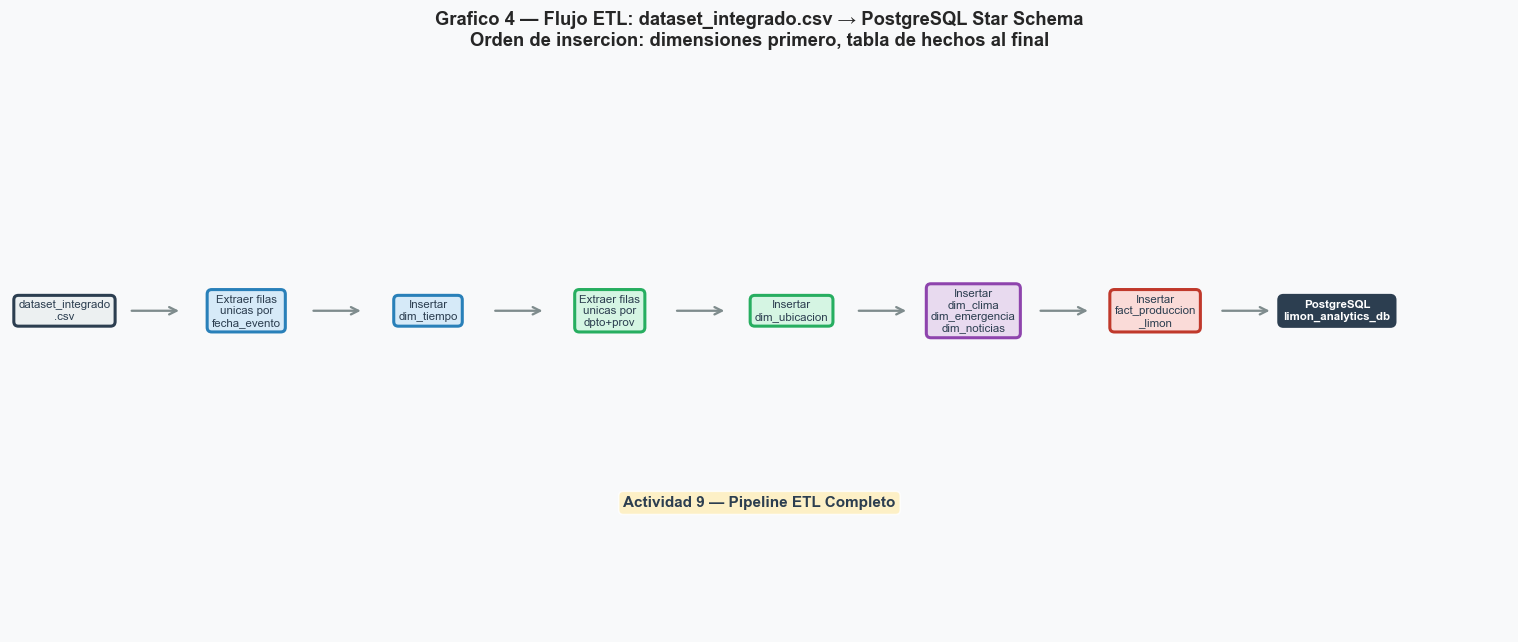

Guardado: pipeline/output/07_dwh/flujo_etl.png


In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

pasos = [
    ('dataset_integrado\n.csv', '#ecf0f1', '#2c3e50'),
    ('Extraer filas\nunicas por\nfecha_evento', '#d6eaf8', '#2980b9'),
    ('Insertar\ndim_tiempo', '#d6eaf8', '#2980b9'),
    ('Extraer filas\nunicas por\ndpto+prov', '#d5f5e3', '#27ae60'),
    ('Insertar\ndim_ubicacion', '#d5f5e3', '#27ae60'),
    ('Insertar\ndim_clima\ndim_emergencia\ndim_noticias', '#e8daef', '#8e44ad'),
    ('Insertar\nfact_produccion\n_limon', '#fadbd8', '#c0392b'),
    ('PostgreSQL\nlimon_analytics_db', '#2c3e50', '#2c3e50'),
]

x_positions = [0.5, 2.2, 3.9, 5.6, 7.3, 9.0, 10.7, 12.4]
for i, ((texto, fcolor, ecolor), x) in enumerate(zip(pasos, x_positions)):
    is_last = (i == len(pasos) - 1)
    text_color = 'white' if is_last else '#2c3e50'
    ax.text(x, 3, texto, ha='center', va='center', fontsize=7.5,
            fontweight='bold' if is_last else 'normal',
            color=text_color,
            bbox=dict(boxstyle='round,pad=0.4', facecolor=fcolor,
                      edgecolor=ecolor, linewidth=2))
    if i < len(pasos) - 1:
        ax.annotate('', xy=(x_positions[i+1]-0.6, 3), xytext=(x+0.6, 3),
                    arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=1.5))

# Etiquetas de actividad
ax.text(7, 1.5, 'Actividad 9 — Pipeline ETL Completo', ha='center', va='center',
        fontsize=10, fontweight='bold', color='#2c3e50',
        bbox=dict(boxstyle='round', facecolor='#ffeeba', alpha=0.8))

ax.set_xlim(0, 14)
ax.set_ylim(0.5, 5)
ax.set_title('Grafico 4 — Flujo ETL: dataset_integrado.csv → PostgreSQL Star Schema\n'
             'Orden de insercion: dimensiones primero, tabla de hechos al final',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g4 = OUTPUT['dwh'] + 'flujo_etl.png'
plt.savefig(g4, dpi=120, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print('Guardado:', g4)


### Interpretacion

**Que muestra:** El orden de insercion de datos en el Star Schema. Las dimensiones deben insertarse ANTES que la tabla de hechos porque la tabla de hechos tiene claves foraneas que referencian las dimensiones.

**Orden critico:** dim_tiempo → dim_ubicacion → dim_clima → dim_emergencia → dim_noticias → fact_produccion_limon. Si se intenta insertar en la tabla de hechos antes que las dimensiones, PostgreSQL lanzara un error de integridad referencial.

**Implicacion para la Actividad 9:** El ETL debe seguir exactamente este orden para que la carga en PostgreSQL sea exitosa.


---
# 7. Resumen de la Actividad 7


In [9]:
print('=' * 70)
print('  ACTIVIDAD 7 COMPLETADA — DISENO DEL STAR SCHEMA')
print('=' * 70)
print()
print('Archivos generados:')
archivos = [
    OUTPUT['dwh'] + 'star_schema_uml.png',
    OUTPUT['dwh'] + 'cardinalidad_tablas.png',
    OUTPUT['dwh'] + 'mapeo_csv_dwh.png',
    OUTPUT['dwh'] + 'flujo_etl.png',
    OUTPUT['dwh'] + 'dwh_star_schema.sql',
]
for path in archivos:
    if os.path.exists(path):
        kb = os.path.getsize(path) // 1024
        print(f'  OK  {os.path.basename(path):<35} {kb} KB')
    else:
        print(f'  FALTA {os.path.basename(path)}')
print()
print('Tablas del Star Schema:')
print(f'  fact_produccion_limon : {n_hechos:,} filas esperadas')
print(f'  dim_tiempo            : {n_tiempo:,} filas')
print(f'  dim_ubicacion         : {n_ubicacion:,} filas')
print(f'  dim_clima             : {n_clima:,} filas')
print(f'  dim_emergencia        : {n_emergencia:,} filas')
print(f'  dim_noticias          : {n_noticias:,} filas')
print()
print('Proximos pasos:')
print('  Actividad 8 -> Crear esquemas en PostgreSQL (ejecutar el DDL)')
print('  Actividad 9 -> Pipeline ETL completo (cargar datos)')


  ACTIVIDAD 7 COMPLETADA — DISENO DEL STAR SCHEMA

Archivos generados:
  OK  star_schema_uml.png                 149 KB
  OK  cardinalidad_tablas.png             34 KB
  OK  mapeo_csv_dwh.png                   83 KB
  OK  flujo_etl.png                       62 KB
  OK  dwh_star_schema.sql                 3 KB

Tablas del Star Schema:
  fact_produccion_limon : 5,880 filas esperadas
  dim_tiempo            : 56 filas
  dim_ubicacion         : 105 filas
  dim_clima             : 5,880 filas
  dim_emergencia        : 5,880 filas
  dim_noticias          : 56 filas

Proximos pasos:
  Actividad 8 -> Crear esquemas en PostgreSQL (ejecutar el DDL)
  Actividad 9 -> Pipeline ETL completo (cargar datos)
